In [6]:
import pandas as pd
import numpy as np

In [2]:
df = pandas.read_csv("mutant_kpc11_probabilities.csv")
df.head()

,Sequence,Mutated_position,Canonical_residue,Mutated_residue,MeanEmbedding,CLSEmbedding,EmbeddingDim,Carbapenemase_Probability,Logit,Predicted_Class,Delta_Logit,Mean_Probability,Mean_Logit,Mean_Delta_Logit,EmbeedingType,Delta_Probability
0,MSLYRRLVLLSCLSWPLAGFSATALTNLVAEPFAKLEQDFGGSIGV...,80,A,H,"[[0.05098888650536537, -0.06942420452833176, -...","[[0.07932128757238388, -0.03487767279148102, 0...",1280,0.922252,2.473341,Carbapenemase,0.668480,0.816921,1.620240,-0.184622,Mean,0.063512
1,MSLYRRLVLLSCLSWPLAGFSATALTNLVAEPFAKLEQDFGGSIGV...,291,G,N,"[[0.05099264159798622, -0.06814805418252945, -...","[[0.07863552123308182, -0.03328976780176163, 0...",1280,0.922252,2.473340,Carbapenemase,0.668478,0.855638,1.884432,0.079570,Mean,0.063512
2,MSLYRRLVLLSCLSWPLAGFSATALTNLVAEPFAKLEQDFGGSIGV...,161,D,S,"[[0.050996605306863785, -0.06757387518882751, ...","[[0.07791221886873245, -0.03557412326335907, 0...",1280,0.922251,2.473332,Carbapenemase,0.668471,0.878708,2.046994,0.242132,Mean,0.063511
3,MSLYRRLVLLSCLSWPLAGFSATALTNLVAEPFAKLEQDFGGSIGV...,152,S,K,"[[0.0509977787733078, -0.06841420382261276, -0...","[[0.08026132732629776, -0.03629283979535103, 0...",1280,0.922251,2.473329,Carbapenemase,0.668467,0.850800,1.797065,-0.007797,Mean,0.063511
4,MSLYRRLVLLSCLSWPLAGFSATALTNLVAEPFAKLEQDFGGSIGV...,102,L,R,"[[0.05098123103380203, -0.06845210492610931, -...","[[0.0794958844780922, -0.03500961512327194, 0....",1280,0.922251,2.473328,Carbapenemase,0.668466,0.878456,2.027360,0.222499,Mean,0.063511


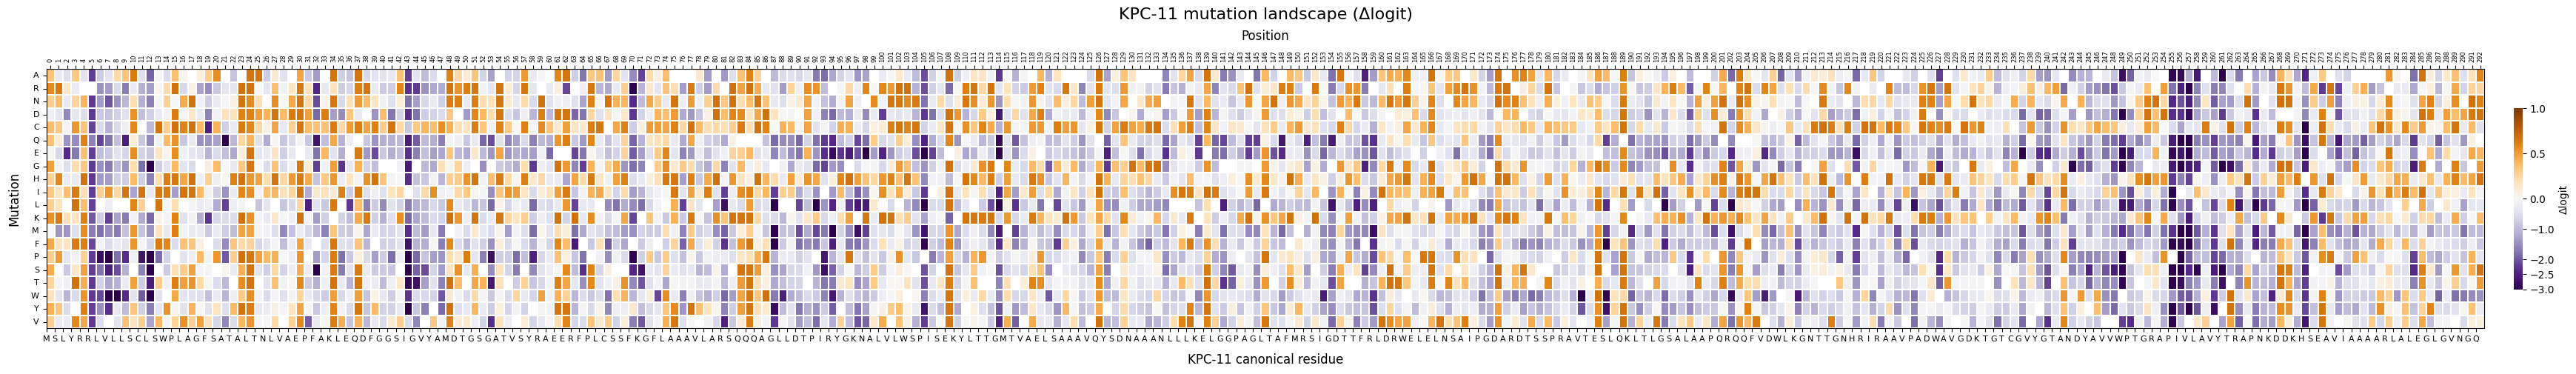

In [178]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

aa_order = list("ARNDCQEGHILKMFPSTWYV")

heatmap_data = df.pivot_table(
    index="Mutated_residue",
    columns="Mutated_position",
    values="Delta_Logit"
).reindex(aa_order)

canonical = (
    df[["Mutated_position","Canonical_residue"]]
    .drop_duplicates()
    .set_index("Mutated_position")
    .sort_index()
)

positions = heatmap_data.columns
residues = [canonical.loc[p,"Canonical_residue"] for p in positions]

fig, ax = plt.subplots(figsize=(35,5))


norm = TwoSlopeNorm(
    vmin=-3,     # unchanged negative range
    vcenter=0,   # zero stays white
    vmax=1     # where full positive color is reached
)
sns.heatmap(
    heatmap_data,
    cmap="PuOr_r",
    norm=norm,
    linewidths=0.003,
    #linecolor="lightgray",
    cbar_kws={
        "label":"Δlogit",
        "pad":0.01,
        "shrink":0.7,
        "aspect":20,
        "ticks":[-3,-2.5,-2,-1,0,0.5,1]   # consistent tick spacing
    },
    ax=ax
)
# bottom labels
ax.set_xticks(range(len(residues)))
ax.set_xticklabels(residues, rotation=0, fontsize=8)
ax.set_xlabel("KPC-11 canonical residue", fontsize=12, labelpad=10)
ax.set_yticklabels(aa_order, rotation=0, fontsize=8)

# top labels
ax_top = ax.twiny()
ax_top.set_xlim(ax.get_xlim())
ax_top.set_xticks([x + 0.5 for x in range(len(positions))])
ax_top.set_xticklabels(positions, rotation=90, fontsize=6)
ax_top.set_xlabel("Position", fontsize=12, labelpad=10)

ax.set_ylabel("Mutation", fontsize=12, labelpad=10)
ax.set_title("KPC-11 mutation landscape (Δlogit)", fontsize=16, pad=10)

plt.tight_layout()
plt.subplots_adjust(top=0.82, bottom=0.12,  left=0.02, right=1.14)
plt.savefig("kpc11_mutation_landscape_logit.png", dpi=600)

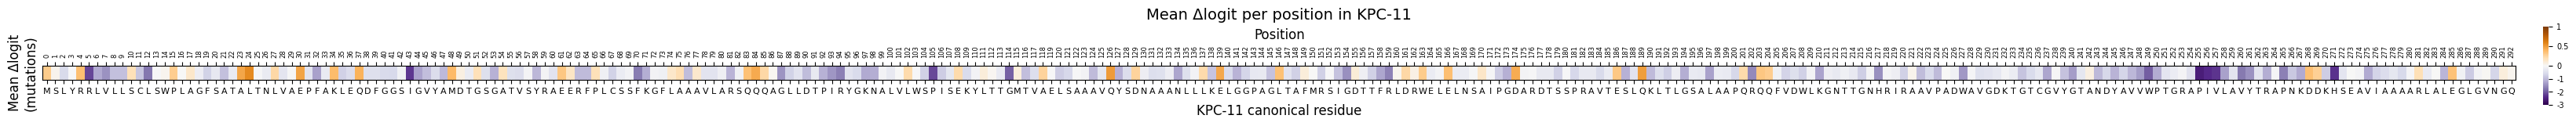

In [188]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import pandas as pd

position_means = df.groupby("Mutated_position")["Delta_Logit"].mean().reindex(positions)
one_row = pd.DataFrame([position_means.values], index=["Mean Δlogit"], columns=positions)

fig = plt.figure(figsize=(35, 1))

# heatmap axis
ax = fig.add_axes([0.03, 0.42, 0.90, 0.18])

# make colorbar a bit wider
cbar_ax = fig.add_axes([0.94, 0.1, 0.002, 1])

norm = TwoSlopeNorm(vmin=-3, vcenter=0, vmax=1)

heat = sns.heatmap(
    one_row,
    cmap="PuOr_r",
    norm=norm,
    linewidths=0,
    cbar=True,
    cbar_ax=cbar_ax,
    cbar_kws={
        "ticks": [-3, -2, -1, 0, 0.5, 1]
    },
    ax=ax
)

# clean colorbar formatting
cbar = heat.collections[0].colorbar
cbar.set_ticks([-3, -2, -1, 0, 0.5, 1])
cbar.set_ticklabels(["-3", "-2", "-1", "0", "0.5", "1"])
cbar.ax.tick_params(labelsize=7)

# bottom labels
ax.set_xticks([x + 0.5 for x in range(len(residues))])
ax.set_xticklabels(residues, rotation=0, fontsize=8)
ax.set_xlabel("KPC-11 canonical residue", fontsize=12, labelpad=8)

# y label
ax.set_ylabel("Mean Δlogit\n(mutations)", fontsize=12)
ax.set_yticks([])

# top labels
ax_top = ax.twiny()
ax_top.set_xlim(ax.get_xlim())
ax_top.set_xticks([x + 0.5 for x in range(len(positions))])
ax_top.set_xticklabels(positions, rotation=90, fontsize=6)
ax_top.set_xlabel("Position", fontsize=12, labelpad=6)

ax.set_title("Mean Δlogit per position in KPC-11", fontsize=14, pad=8)

fig.savefig(
    "kpc11_mean_delta_logit_strip.png",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.02
)

plt.show()

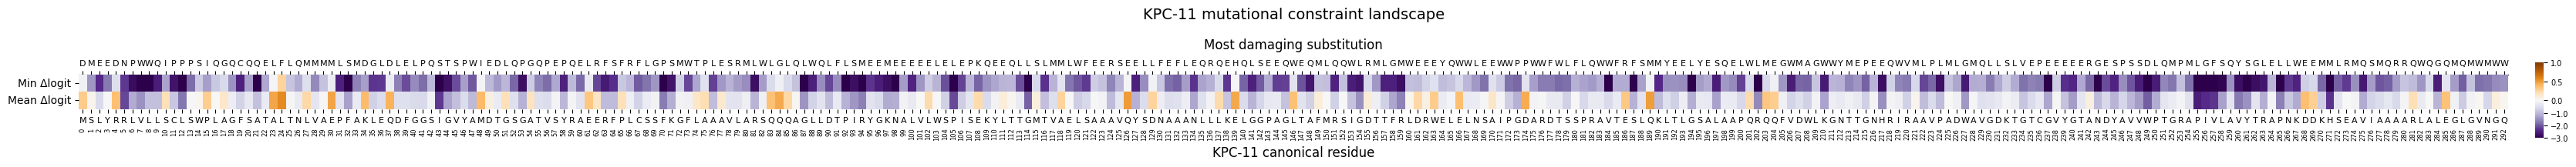

In [205]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import pandas as pd

# --- compute statistics ---
position_means = df.groupby("Mutated_position")["Delta_Logit"].mean().reindex(positions)
position_min = df.groupby("Mutated_position")["Delta_Logit"].min().reindex(positions)

# worst mutation per position
worst_mut = (
    df.sort_values("Delta_Logit")
      .groupby("Mutated_position")
      .first()["Mutated_residue"]
      .reindex(positions)
)

# 2-row matrix
two_rows = pd.DataFrame(
    [position_min.values, position_means.values],
    index=["Min Δlogit", "Mean Δlogit"],
    columns=positions
)

fig = plt.figure(figsize=(35,1.4))

# heatmap axis
ax = fig.add_axes([0.03,0.42,0.90,0.32])

# colorbar axis
cbar_ax = fig.add_axes([0.94,0.15,0.003,0.7])

norm = TwoSlopeNorm(vmin=-3, vcenter=0, vmax=1)

heat = sns.heatmap(
    two_rows,
    cmap="PuOr_r",
    norm=norm,
    linewidths=0,
    cbar=True,
    cbar_ax=cbar_ax,
    cbar_kws={"ticks":[-3,-2,-1,0,0.5,1]},
    ax=ax
)

# colorbar formatting
cbar = heat.collections[0].colorbar
cbar.ax.tick_params(labelsize=7)

# y labels
ax.set_yticklabels(["Min Δlogit","Mean Δlogit"], rotation=0, fontsize=10)

# canonical residues (main x-axis)
ax.set_xticks([x + 0.5 for x in range(len(residues))])
ax.set_xticklabels(residues, rotation=0, fontsize=8)
ax.set_xlabel("KPC-11 canonical residue", fontsize=12, labelpad=20)

# --- position axis BELOW canonical residues ---
ax_pos = ax.secondary_xaxis('bottom')
ax_pos.set_xticks([x + 0.5 for x in range(len(positions))])
ax_pos.spines['bottom'].set_position(('outward', 14))
#ax_pos.set_xlabel("Position", fontsize=12, labelpad=12)
ax_pos.set_xticklabels(positions, rotation=90, fontsize=6)
ax_pos.spines['bottom'].set_visible(False)
ax_pos.tick_params(axis='x', length=0)

# --- top axis: worst mutation residue ---
ax_top = ax.secondary_xaxis('top')
ax_top.set_xticks([x + 0.5 for x in range(len(worst_mut))])
ax_top.set_xticklabels(worst_mut, rotation=0, fontsize=8)
ax_top.set_xlabel("Most damaging substitution", fontsize=12, labelpad=10)

ax.set_title("KPC-11 mutational constraint landscape", fontsize=14, pad=18)

fig.savefig(
    "kpc11_min_mean_delta_logit_strip.png",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.02
)

plt.show()

In [25]:
#dataset UMAP of all mutants
import pandas as pd
import numpy as np
mutants = pd.read_csv("mutant_kpc11_probabilities.csv")
mutants.head()

,Sequence,Mutated_position,Canonical_residue,Mutated_residue,MeanEmbedding,CLSEmbedding,EmbeddingDim,Carbapenemase_Probability,Logit,Predicted_Class,Delta_Logit,Mean_Probability,Mean_Logit,Mean_Delta_Logit,EmbeedingType,Delta_Probability,Mean_Delta_Probability,Min_Logit,Max_Logit
0,MSLYRRLVLLSCLSWPLAGFSATALTNLVAEPFAKLEQDFGGSIGV...,255,P,E,"[[0.05796727538108826, -0.06942269206047058, -...","[[0.08032112568616867, -0.03459315374493599, 0...",1280,0.255149,-1.071336,Non-carbapenemase,-2.876197,0.341683,-0.739574,-2.544435,Mean,-0.603590,-0.517057,-1.886602,1.37362
1,MSLYRRLVLLSCLSWPLAGFSATALTNLVAEPFAKLEQDFGGSIGV...,255,P,L,"[[0.06107009947299957, -0.06913203001022339, -...","[[0.07972662150859833, -0.034166812896728516, ...",1280,0.131632,-1.886602,Non-carbapenemase,-3.691463,0.341683,-0.739574,-2.544435,Mean,-0.727107,-0.517057,-1.886602,1.37362
2,MSLYRRLVLLSCLSWPLAGFSATALTNLVAEPFAKLEQDFGGSIGV...,255,P,K,"[[0.05409065634012222, -0.06780257821083069, -...","[[0.08035734295845032, -0.03513117879629135, 0...",1280,0.797964,1.373620,Carbapenemase,-0.431241,0.341683,-0.739574,-2.544435,Mean,-0.060775,-0.517057,-1.886602,1.37362
3,MSLYRRLVLLSCLSWPLAGFSATALTNLVAEPFAKLEQDFGGSIGV...,255,P,Q,"[[0.057415228337049484, -0.06862905621528625, ...","[[0.0809495598077774, -0.03441504016518593, 0....",1280,0.320343,-0.752197,Non-carbapenemase,-2.557058,0.341683,-0.739574,-2.544435,Mean,-0.538397,-0.517057,-1.886602,1.37362
4,MSLYRRLVLLSCLSWPLAGFSATALTNLVAEPFAKLEQDFGGSIGV...,255,P,V,"[[0.059363480657339096, -0.0705282986164093, -...","[[0.07907991856336594, -0.03507959470152855, 0...",1280,0.163617,-1.631557,Non-carbapenemase,-3.436419,0.341683,-0.739574,-2.544435,Mean,-0.695122,-0.517057,-1.886602,1.37362


In [7]:
# umap of all training dataset coloured by family

data = pd.read_csv("embeddings.csv")
data = data[["Family", "MeanEmbedding", "Carbapenemase"]]

class_A = [
    "KPC",
    "IMI",
    "SME",
    #"GES",
    "TEM",
    "SHV",
    "CTX-M",
    "VEB"
]

data = data[data["Family"].isin(class_A)]
data.head()

,Family,MeanEmbedding,Carbapenemase
0,SHV,"[[0.05962217226624489, -0.07687947154045105, 0...",0
1,CTX-M,"[[0.05877629667520523, -0.06891713291406631, -...",0
4,TEM,"[[0.059695929288864136, -0.05530138313770294, ...",0
5,TEM,"[[0.056167904287576675, -0.04905174672603607, ...",0
6,TEM,"[[0.07185406237840652, -0.056960783898830414, ...",0


Embedding matrix shape: (998, 1280)


/opt/anaconda3/envs/jupyter-env/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


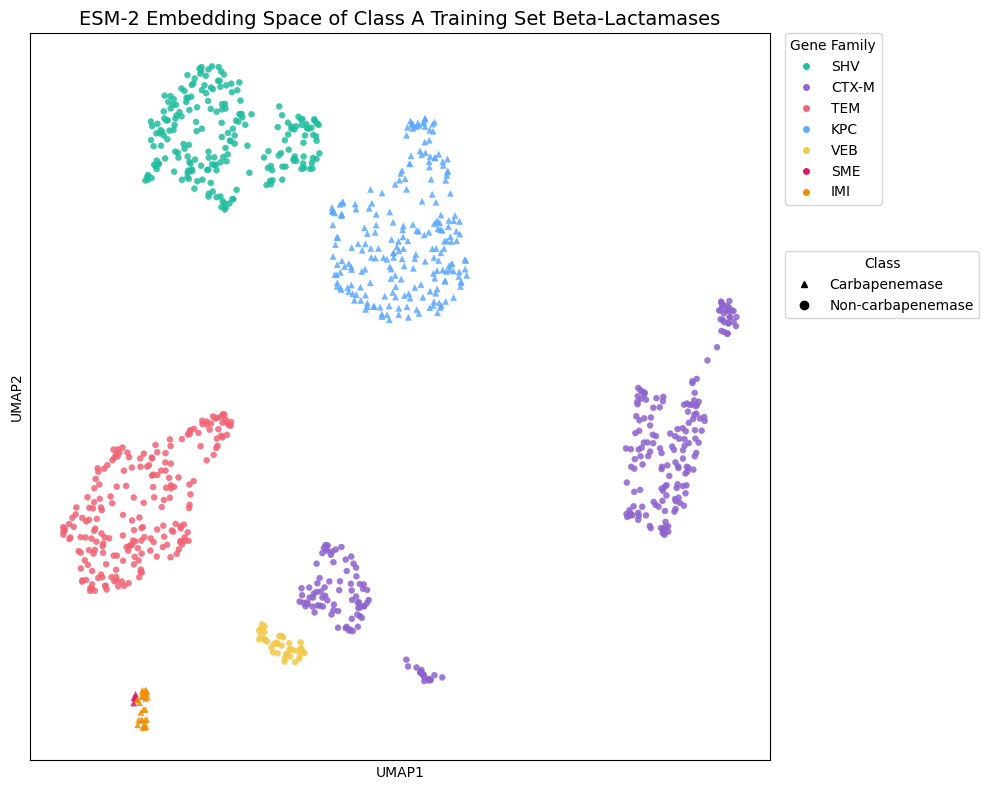

In [33]:
import ast
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import umap

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from matplotlib.lines import Line2D

# ----------------------------
# Parse embeddings
# ----------------------------
embs = np.vstack(
    data["MeanEmbedding"].apply(lambda x: np.array(ast.literal_eval(x), dtype=float))
)

print("Embedding matrix shape:", embs.shape)

# ----------------------------
# Standardize + PCA
# ----------------------------
embs_scaled = StandardScaler().fit_transform(embs)

n_pcs = min(4, embs_scaled.shape[0], embs_scaled.shape[1])
embs_pca = PCA(n_components=n_pcs, random_state=42).fit_transform(embs_scaled)

# ----------------------------
# UMAP
# ----------------------------
reducer = umap.UMAP(
    random_state=11,
    n_neighbors=40,
    min_dist=0.3,
    metric="cosine",
    spread=1.0
)

embeddings = reducer.fit_transform(embs_pca)

data = data.copy()
data["UMAP1"] = embeddings[:, 0]
data["UMAP2"] = embeddings[:, 1]

# ----------------------------
# Pull clusters inward properly
# ----------------------------
within_shrink = 0.40   # shrink each family internally
between_shrink = 0.2  # move family centroids toward overall center

data["UMAP1_plot"] = np.nan
data["UMAP2_plot"] = np.nan

global_x = data["UMAP1"].mean()
global_y = data["UMAP2"].mean()

for fam in data["Family"].unique():
    mask = data["Family"] == fam

    x = data.loc[mask, "UMAP1"].to_numpy()
    y = data.loc[mask, "UMAP2"].to_numpy()

    cx = x.mean()
    cy = y.mean()

    # tighten points within family
    x_tight = cx + within_shrink * (x - cx)
    y_tight = cy + within_shrink * (y - cy)

    # move family centroid inward toward global center
    cx_new = global_x + between_shrink * (cx - global_x)
    cy_new = global_y + between_shrink * (cy - global_y)

    # shift tightened cluster to new centroid
    data.loc[mask, "UMAP1_plot"] = x_tight + (cx_new - cx)
    data.loc[mask, "UMAP2_plot"] = y_tight + (cy_new - cy)

# ----------------------------
# Style mappings
# ----------------------------
family_order = ["SHV", "CTX-M", "TEM", "KPC", "VEB", "SME", "IMI"]

palette = {
    "SHV":   "#20BD9F",  # teal
    "CTX-M": "#8E63CE",  # purple
    "TEM":   "#F06374",  # coral red
    "KPC":   "#5DA9FF",  # blue
    "VEB":   "#F2C94C",  # yellow
    "SME":   "#D81B60",  # magenta
    "IMI":   "#F18F01"   # orange
}
# 1 = carbapenemase, 0 = non-carbapenemase
style_order = [1, 0]
markers = {
    0: "o",   # noncarbapenemase = circle
    1: "^"    # carbapenemase = triangle
}

# ----------------------------
# Plot
# ----------------------------
fig, ax = plt.subplots(figsize=(10, 8))

sns.scatterplot(
    data=data,
    x="UMAP1_plot",
    y="UMAP2_plot",
    hue="Family",
    hue_order=family_order,
    style="Carbapenemase",
    style_order=style_order,
    markers=markers,
    palette=palette,
    edgecolor=None,
    alpha=0.85,
    s=18,
    legend=False,
    ax=ax
)

ax.set_title("ESM-2 Embedding Space of Class A Training Set Beta-Lactamases", fontsize=14)
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")

# ----------------------------
# Custom legends
# ----------------------------
family_handles = [
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        markerfacecolor=palette[fam],
        markersize=6,
        linestyle="None",
        label=fam
    )
    for fam in family_order
]

legend1 = ax.legend(
    handles=family_handles,
    title="Gene Family",
    bbox_to_anchor=(1.02, 1.00),
    loc="upper left",
    borderaxespad=0,
    frameon=True
)
ax.add_artist(legend1)

marker_handles = [
    Line2D(
        [0], [0],
        marker="^",
        color="black",
        markerfacecolor="black",
        markersize=5,
        linestyle="None",
        label="Carbapenemase"
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="black",
        markerfacecolor="black",
        markersize=6,
        linestyle="None",
        label="Non-carbapenemase"
    )
]

legend2 = ax.legend(
    handles=marker_handles,
    title="Class",
    bbox_to_anchor=(1.02, 0.7),
    loc="upper left",
    borderaxespad=0,
    frameon=True
)
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
plt.savefig("training_umap_family_shrunk.png", dpi=300, bbox_inches="tight")
plt.show()

Figure X. ESM-2 embedding space of class A β-lactamase training sequences.
Protein sequence embeddings generated using the ESM-2 protein language model were projected into two dimensions using Uniform Manifold Approximation and Projection (UMAP). Each point represents a β-lactamase sequence from the training dataset, colored by gene family (SHV, CTX-M, TEM, KPC, VEB, SME, IMI). Distinct clusters corresponding to individual families demonstrate that the pretrained model encodes biologically meaningful sequence relationships directly from amino-acid sequence. Marker shape indicates carbapenemase classification, with triangles representing carbapenemases and circles representing non-carbapenemases. The clear separation of families in embedding space illustrates the ability of protein language model embeddings to capture functional and evolutionary structure among class A β-lactamases.